# 9 bit shor code


In [46]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator


# 9 data qubits + 1 classical bit (for demo)
qc = QuantumCircuit(12,3)
# ----- Shor Encoding -----

# Phase-flip protection

qc.cx(0, 3)
qc.cx(0, 6)
qc.cx(0,9)
# qc.h(0)
#qc.h(3)
#qc.h(6)


# Bit-flip protection (3 blocks)
for i in [0, 3, 6]:
    qc.cx(i, i+1)
    qc.cx(i, i+2)
#introduce error
qc.x(0)
#getting z mesurments
qc.cx(0,9) 
qc.cx(1,9)
qc.measure(9,0)
qc.cx(1,10)
qc.cx(2,10)
qc.measure(10,1)
qc.cx(0,11)
qc.cx(2,11)
qc.measure(11,2)
# --------------------------------------------------
# Run on simulator
# --------------------------------------------------

sim = AerSimulator()
job = sim.run(qc, shots=1024)
result = job.result()
counts = result.get_counts()

print("Raw syndrome:", counts)

# --------------------------------------------------
# Classical decoding
# --------------------------------------------------

syndrome = list(counts.keys())[0]
c0 = int(syndrome[2])   # because Qiskit reverses bit order
c1 = int(syndrome[1])
c2 = int(syndrome[0])

if c0 == 0 and c1 == 0 and c2==0:
    print("No bit flip detected")
elif c0 == 1 and c1 == 1:
    print("Bit flip on qubit 1")
    qc.x(1)
    print('flip correct on qubit 1')
elif c1 == 1 and c2 == 1:
    print("Bit flip on qubit 2")
    qc.x(2)
    print('flip corrected on qubit 2')
elif c0 == 1 and c2 == 1:
    print("Bit flip on qubit 0")
    qc.x(0)
    print('flip corrected on qbit 0')
## qc.draw("mpl")


Raw syndrome: {'101': 1024}
Bit flip on qubit 0
flip corrected on qbit 0


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

# ======================================================
# 1) Connect to IBM Quantum
# ======================================================
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
print("Using IBM backend:", backend.name)

# ======================================================
# 2) Build Shor bit-flip detection circuit
# ======================================================
# q0,q1,q2   → data qubits
# q9,q10,q11 → ancillas
# c0,c1,c2   → Z01, Z12, Z02

qc = QuantumCircuit(12, 3)

# Encode |ψ> → |ψψψ>
qc.cx(0, 1)
qc.cx(0, 2)

# Inject a bit-flip (change this to test)
# qc.x(1)   # try qc.x(0) or qc.x(2)

# Z0 Z1 → ancilla 9 → c0
qc.cx(0, 9)
qc.cx(1, 9)
qc.measure(9, 0)

# Z1 Z2 → ancilla 10 → c1
qc.cx(1, 10)
qc.cx(2, 10)
qc.measure(10, 1)

# Z0 Z2 → ancilla 11 → c2
qc.cx(0, 11)
qc.cx(2, 11)
qc.measure(11, 2)

# ======================================================
# 3) Transpile for IBM hardware
# ======================================================
qc_t = transpile(qc, backend)

# ======================================================
# 4) Run on IBM Quantum (Sampler V2)
# ======================================================
sampler = Sampler(backend)
job = sampler.run([qc_t], shots=1024)
result = job.result()

# ======================================================
# 5) Extract classical results (BitArray → bitstrings)
# ======================================================
bit_array = result[0].data.c      # BitArray
arr = bit_array.array            # numpy array of bytes, shape (shots, bytes)

bitstrings = []
for row in arr:
    value = int.from_bytes(row, byteorder="big")
    bitstrings.append(format(value, "03b"))   # 3 classical bits

# Count frequencies
counts = {}
for s in bitstrings:
    counts[s] = counts.get(s, 0) + 1

print("Raw IBM counts:", counts)

# Most frequent syndrome
syndrome = max(counts, key=counts.get)

# Qiskit order: c2 c1 c0
c0 = int(syndrome[2])   # Z0Z1
c1 = int(syndrome[1])   # Z1Z2
c2 = int(syndrome[0])   # Z0Z2

print("Syndrome bits (Z01, Z12, Z02):", c0, c1, c2)

# ======================================================
# 6) Decode which qubit flipped
# ======================================================
if c0 == 0 and c1 == 0 and c2 == 0:
    print("No bit flip detected")
elif c0 == 1 and c2 == 1:
    print("Bit flip on qubit 0")
elif c0 == 1 and c1 == 1:
    print("Bit flip on qubit 1")
elif c1 == 1 and c2 == 1:
    print("Bit flip on qubit 2")
else:
    print("Inconclusive (hardware noise)")


qiskit_runtime_service.__init__:WARNING:2026-01-13 13:33:46,780: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: Rajat Yadav. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-13 13:33:47,729: Loading instance: Rajat Yadav, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-13 13:33:52,521: Using instance: Rajat Yadav, plan: open


Using IBM backend: ibm_fez


In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

qc = QuantumCircuit(5, 2)

qc.h(0)

qc.cx(0,1)
qc.cx(0,2)

qc.x(1)

qc.cx(0,3)
qc.cx(1,3)

qc.cx(1,4)
qc.cx(2,4)

qc.measure(3,0)
qc.measure(4,1)

sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1).result()
counts = result.get_counts()

print("Raw output:", counts)

syndrome = list(counts.keys())[0]
c0 = int(syndrome[1])   # because Qiskit reverses bit order
c1 = int(syndrome[0])

print("Syndrome Z0Z1 =", c0)
print("Syndrome Z1Z2 =", c1)

if c0==0 and c1==0:
    print("No error")
elif c0==1 and c1==0:
    print("Error on qubit 0")
    qc.x(0)
elif c0==1 and c1==1:
    print("Error on qubit 1")
    qc.x(1)
elif c0==0 and c1==1:
    print("Error on qubit 2")
    qc.x(2)

qc.cx(0,3)
qc.cx(1,3)

qc.cx(1,4)
qc.cx(2,4)

qc.measure(3,0)
qc.measure(4,1)
sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1).result()
counts = result.get_counts()

print("Raw output:", counts)



Raw output: {'11': 1}
Syndrome Z0Z1 = 1
Syndrome Z1Z2 = 1
Error on qubit 1
Raw output: {'11': 1}


{'011': 525, '111': 499}


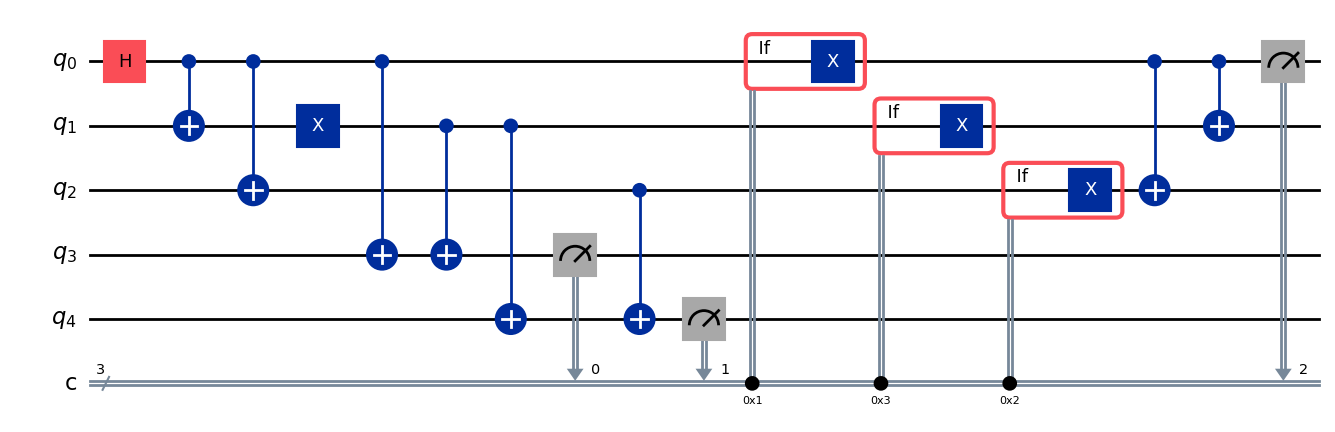

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile

qc = QuantumCircuit(5, 3)

qc.h(0)
qc.cx(0,1)
qc.cx(0,2)

qc.x(1)

qc.cx(0,3)
qc.cx(1,3)
qc.cx(1,4)
qc.cx(2,4)

qc.measure(3,0)   # c0 = Z0Z1
qc.measure(4,1)   # c1 = Z1Z2

# NOTE: classical value is (c1 c0) in binary

with qc.if_test((qc.cregs[0], 1)):   # 01 → Z0Z1=1, Z1Z2=0 → qubit 0
    qc.x(0)

with qc.if_test((qc.cregs[0], 3)):   # 11 → Z0Z1=1, Z1Z2=1 → qubit 1
    qc.x(1)

with qc.if_test((qc.cregs[0], 2)):   # 10 → Z0Z1=0, Z1Z2=1 → qubit 2
    qc.x(2)
qc.cx(0,2)
qc.cx(0,1)

qc.measure(0,2)

sim = AerSimulator()
tqc = transpile(qc, sim)
result = sim.run(tqc, shots=1024).result()

print(result.get_counts())
qc.draw('mpl')


**# for phase flip
**